# HODDIES: an Abacus small-box tutorial

Generate a single-tracer **LRG** mock and a joint **LRG + ELG** mock from the same
local simulation. Plot the halo mass function (HMF), measured halo occupations
(HOD), projected correlations, correlation multipoles, and power-spectrum
multipoles, then estimate each tracer's large-scale galaxy bias.

This example uses `AbacusSummit_small_c000_ph3000` at **z = 0.5** in
`/home/antoine/Bureau/Transfert/postdoc/Abacus_sims`.
Run the cells in order with the Python environment used for HODDIES: NumPy,
Matplotlib, Numba, AbacusUtils, mpytools, pycorr with Corrfunc, pypower, and
cosmoprimo with CLASS. The first run also compiles the Numba kernels.

Positions and separations are in comoving $h^{-1}\mathrm{Mpc}$, halo masses in
$h^{-1}M_\odot$, and velocities in $\mathrm{km\,s^{-1}}$.
These HOD parameters illustrate the workflow; they are not fitted to data.

In [1]:
from pathlib import Path
from copy import deepcopy
import os
import sys
import tempfile

# Support opening the notebook from either the repository or Notebooks/.
repo_root = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "HODDIES" / "hod.py").is_file()),
    None,
)
if repo_root is not None:
    sys.path.insert(0, str(repo_root))

# Keep compiled kernels separate from caches created by older notebooks.
os.environ.setdefault(
    "NUMBA_CACHE_DIR", str(Path(tempfile.gettempdir()) / "hoddies-tutorial-numba")
)

import numpy as np
import matplotlib.pyplot as plt
from HODDIES import HOD
from HODDIES.sim_loader import AbacusSummitSim

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
COLORS = {"LRG": "tab:red", "ELG": "tab:blue", "LRG_ELG": "tab:purple"}
NTHREADS = 4
FIX_SEED = 42

## 1. Load the simulation once

Pass the parent Abacus directory to `path_to_sim`: the loader adds `small/`
for this simulation name. It reads the cleaned CompaSO halo catalogue and
obtains the box size from its header. A cut at
$\log_{10}(M_h/[h^{-1}M_\odot])=11.2$ removes low-mass halos.

The default below places satellites analytically. Set `USE_PARTICLES=True`
to load halo-associated particles and use them for satellite assignment.
For particle satellites the velocity prescription is
$\boldsymbol{v}_{\rm sat}=\boldsymbol{v}_h+
f_{\sigma_v}(\boldsymbol{v}_{\rm p}-\boldsymbol{v}_h)$:
the default `f_sigv=1` preserves particle velocities.

In [2]:
ABACUS_ROOT = Path("/home/antoine/Bureau/Transfert/postdoc/Abacus_sims")
SIM_NAME = "AbacusSummit_small_c000_ph3000"
Z_SIM = 0.5
MASS_CUT = 11.2
USE_PARTICLES = False

snapshot = ABACUS_ROOT / "small" / SIM_NAME / "halos" / f"z{Z_SIM:.3f}"
if not (snapshot / "halo_info").is_dir():
    raise FileNotFoundError(f"Halo catalogue not found: {snapshot}")

simulation = AbacusSummitSim(
    path_to_sim=str(ABACUS_ROOT),
    sim_name=SIM_NAME,
    z_simu=Z_SIM,
    mass_cut=MASS_CUT,
    load_particles=USE_PARTICLES,
    nthreads=NTHREADS,
)
volume = float(simulation.boxsize) ** 3
print(f"Loaded {len(simulation.hcat):,} halos at z={Z_SIM}")
print(f"Box side: {simulation.boxsize:g} Mpc/h; threads: {simulation.nthreads}")

[000000.00]  10-02 17:51 AbacusSummitSim              INFO     Initializing AbacusSummitSim.
[000000.00]  10-02 17:51 AbacusSummitSim              INFO     Load Compaso catalogue from /home/antoine/Bureau/Transfert/postdoc/Abacus_sims/small/AbacusSummit_small_c000_ph3000/halos/z0.500 ...


/home/antoine/.local/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


[000000.99]  10-02 17:51 AbacusSummitSim              INFO     Done took 00:00:00
[000001.00]  10-02 17:51 AbacusSummitSim              INFO     Compute required columns...
[000001.25]  10-02 17:51 AbacusSummitSim              INFO     Done took 00:00:00
Loaded 2,903,574 halos at z=0.5
Box side: 500 Mpc/h; threads: 4


## 2. Plot the halo mass function

The HMF is the number of **input halos**, divided by the simulation volume
and the logarithmic mass-bin width: $dn_h/d\log_{10}M_h$.
The same bins will be used to measure the mean occupations below.

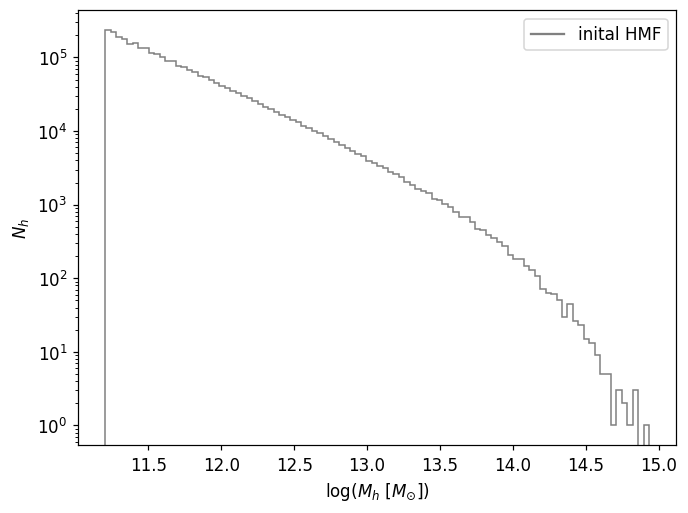

In [3]:
simulation.plot_HMF()

## 3. Choose HOD parameters and measurement settings

LRG centrals use the softened-step `SHOD` model; ELG centrals use `mHMQ`.
Satellites use a power-law occupation. With `USE_PARTICLES=False`, they use
an analytic NFW spatial profile and the `rd_normal` velocity prescription. `density=None` keeps the supplied
HOD amplitudes, rather than rescaling them to a target number density.
Logarithmic mass parameters are in $\log_{10}(h^{-1}M_\odot)$.

Clustering is measured in redshift space along the $z$ direction.
A $128^3$ FFT mesh and modest bin counts keep this example inexpensive;
increase the mesh and check convergence for precision measurements.

In [4]:
LRG_PARAMETERS = dict(
    HOD_model="SHOD", Ac=0.6, log_Mcent=12.8, sigma_M=0.4,
    satellites=True, sat_HOD_model="Nsat_pow_law",
    As=0.6, M_0=12.8, M_1=13.8, alpha=1.0,
    density=None, nu=1.0, link_sat_to_central=False, conformity_bias=False,
    vel_sat="rd_normal", f_sigv=1.0, vsmear=0.0,
)
ELG_PARAMETERS = dict(
    HOD_model="mHMQ", Ac=0.12, log_Mcent=11.8, sigma_M=0.3, gamma=2.0,
    satellites=True, sat_HOD_model="Nsat_pow_law",
    As=0.05, M_0=11.8, M_1=12.8, alpha=0.8,
    density=None, nu=1.0, link_sat_to_central=False, conformity_bias=False,
    vel_sat="rd_normal", f_sigv=1.0, vsmear=0.0,
)
CLUSTERING_SETTINGS = {
    "rsd": True,
    "los": "z",
    "xi_rppi": {
        "rp_min": 0.3, "rp_max": 25.0, "n_rp_bins": 18, "pimax": 40,
    },
    "xi_smu": {
        "smin": 0.3, "smax": 40.0, "n_s_bins": 20,
        "n_mu_bins": 81, "multipole_index": [0, 2],
    },
    "power_spectrum": {
        "nmesh": 128, "kmin": 0.02, "kmax": 0.3, "n_k_bins": 28,
        "multipole_index": [0, 2], "resampler": "tsc", "interlacing": 2,
    },
}

## 4. Generate a single-tracer mock

The simulation object is passed directly to `HOD`, so the halo catalogue
does not need to be read again. `make_mock_cat` returns one `mpytools.Catalog`:
`TRACER` identifies the population, and `Central` is 1 for centrals and 0 for
satellites. Record the seed and thread count to reproduce the draw.

In [5]:
def describe_mock(mock):
    print(f"{'Tracer':<8} {'N galaxies':>12} {'n [h^3/Mpc^3]':>17} {'f_sat':>10}")
    for tracer in np.unique(mock["TRACER"]):
        selected = mock[mock["TRACER"] == tracer]
        fsat = np.mean(selected["Central"] == 0)
        print(f"{tracer:<8} {len(selected):>12,} {len(selected)/volume:>17.4e} {fsat:>10.3f}")

hod_single = HOD(
    simulation, tracers=["LRG"], LRG=deepcopy(LRG_PARAMETERS),
    clustering_settings=deepcopy(CLUSTERING_SETTINGS),
    use_particles=USE_PARTICLES, use_assembly_bias=False,
    nthreads=NTHREADS, seed=FIX_SEED,
)
mock_single = hod_single.make_mock_cat(fix_seed=FIX_SEED)
describe_mock(mock_single)
print("Catalogue columns:", mock_single.columns())

setup_logger True
[000005.38]  10-02 17:51 HOD                          INFO     Initializing HOD.
[000005.39]  10-02 17:51 HOD                          INFO     Set number of threads to 4


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


[000005.71]  10-02 17:51 AbacusSummitSim              INFO     Initialize Abacus c000 cosmology
[000005.72]  10-02 17:51 HOD                          INFO     Create mock catalog for ['LRG']
[000005.73]  10-02 17:51 HOD                          INFO     Run HOD for LRG
[000015.29]  10-02 17:51 HOD                          INFO     LRG mock catalogue done in 9.56 sec
[000015.29]  10-02 17:51 HOD                          INFO     Total time to create the mock catalog: 9.57 seconds
[000015.29]  10-02 17:51 HOD                          INFO     Total number of LRG: 61712 with 53289 central, 8423 satellite and a satellites fraction: 0.14
[000015.29]  10-02 17:51 HOD                          INFO     Total number of galaxies in the catalog: 61712
[000015.30]  10-02 17:51 HOD                          INFO     Total number of centrals: 53289
[000015.30]  10-02 17:51 HOD                          INFO     Total number of satellites: 8423
Tracer     N galaxies     n [h^3/Mpc^3]      f_sat
LRG    

### Measure the HOD from the mock

In each mass bin, divide the number of central or satellite galaxies by the
number of **all input halos**, including those with no galaxies. These curves
measure $\langle N_c|M_h\rangle$ and $\langle N_s|M_h\rangle$ in the realised
mock; fluctuations are expected in sparsely populated mass bins.

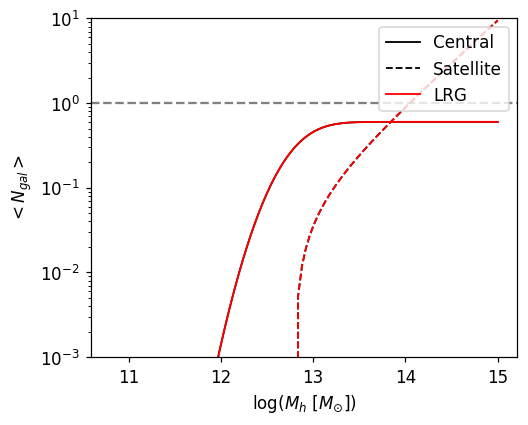

In [6]:
hod_single.HOD_plot()

### Measure and plot clustering

Compute $w_p(r_p)$ with $\pi_{\max}=40\,h^{-1}\mathrm{Mpc}$,
$\xi_0(s)$ and $\xi_2(s)$, and $P_0(k)$ and $P_2(k)$.
Results are dictionaries indexed by statistic and tracer pair, for example
`stats_single["wp"]["LRG_LRG"]` contains `(rp, wp)`.

The helper below uses `get_PS` for auto-spectra, which subtracts Poisson
shot noise, and the pair interface for cross-spectra. Multipoles are ordered
as `[0, 2]` throughout this example.

ValueError: Particle subsample is required to compute ΔΣ(R).

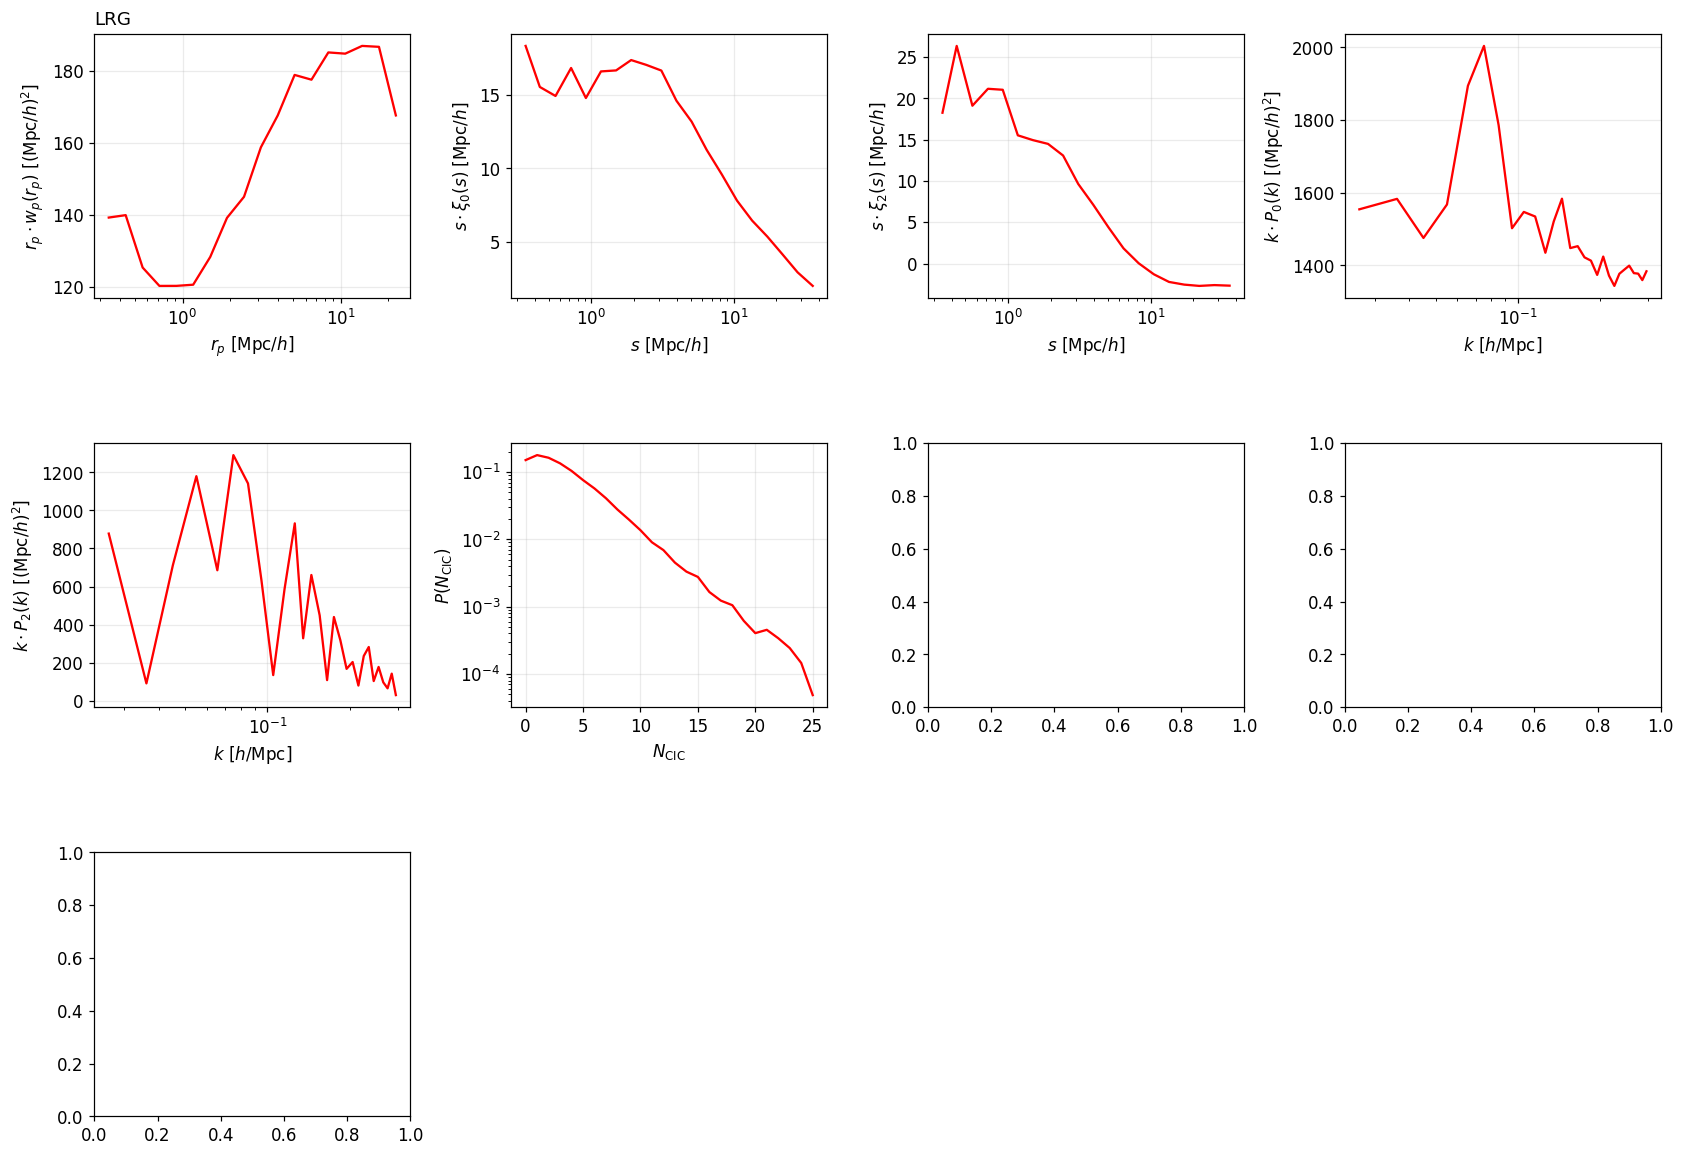

In [11]:
fig = hod_single.plot_stats(mock_single, stats=["ALL"])

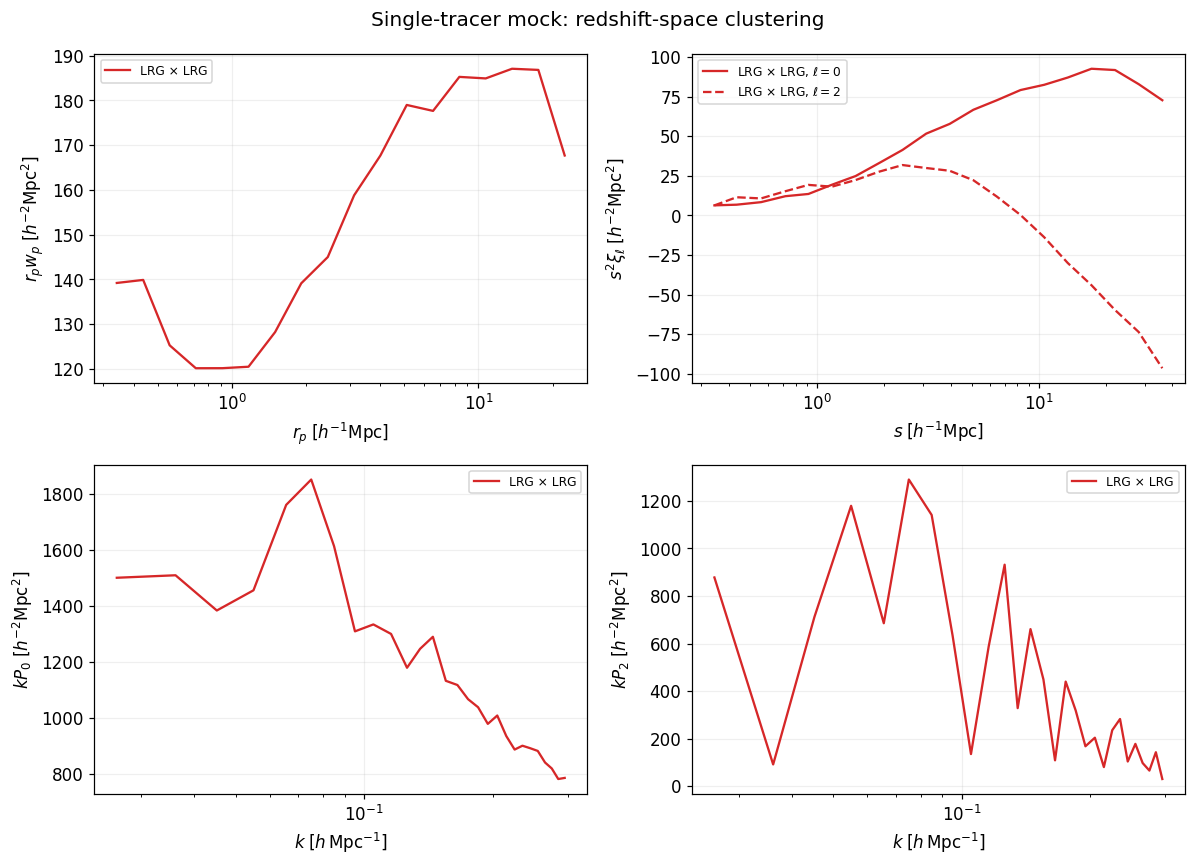

In [7]:
def measure_clustering(hod, mock, tracers):
    result = hod.compute_stats(mock, stat=["wp", "xi_ells"], tracers=tracers)
    # Keep cross-spectra, then use genuine auto-spectra for diagonal pairs.
    result["power_spectrum"] = (
        hod.get_cross_PS(mock, tracers=tracers, verbose=False) if len(tracers) > 1 else {}
    )
    for tracer in tracers:
        result["power_spectrum"][f"{tracer}_{tracer}"] = hod.get_PS(
            mock, tracers=tracer, ells=[0, 2], verbose=False
        )
    return result

def plot_clustering(result, title):
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    for pair in result["wp"]:
        tr1, tr2 = pair.split("_")
        color = COLORS[tr1] if tr1 == tr2 else COLORS["LRG_ELG"]
        label = f"{tr1} × {tr2}"
        rp, wp = result["wp"][pair]
        s, xi = result["xi_ells"][pair]
        k, power = result["power_spectrum"][pair]
        axes[0, 0].semilogx(rp, rp * wp, color=color, label=label)
        axes[0, 1].semilogx(s, s**2 * xi[0], color=color, label=label + r", $\ell=0$")
        axes[0, 1].semilogx(s, s**2 * xi[1], "--", color=color, label=label + r", $\ell=2$")
        axes[1, 0].semilogx(k, k * power[0], color=color, label=label)
        axes[1, 1].semilogx(k, k * power[1], color=color, label=label)
    labels = [
        (r"$r_p\;[h^{-1}\mathrm{Mpc}]$", r"$r_p w_p\;[h^{-2}\mathrm{Mpc}^2]$"),
        (r"$s\;[h^{-1}\mathrm{Mpc}]$", r"$s^2\xi_\ell\;[h^{-2}\mathrm{Mpc}^2]$"),
        (r"$k\;[h\,\mathrm{Mpc}^{-1}]$", r"$kP_0\;[h^{-2}\mathrm{Mpc}^2]$"),
        (r"$k\;[h\,\mathrm{Mpc}^{-1}]$", r"$kP_2\;[h^{-2}\mathrm{Mpc}^2]$"),
    ]
    for ax, (xlabel, ylabel) in zip(axes.flat, labels):
        ax.set(xlabel=xlabel, ylabel=ylabel)
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

stats_single = measure_clustering(hod_single, mock_single, ["LRG"])
plot_clustering(stats_single, "Single-tracer mock: redshift-space clustering")

## 5. Generate a joint LRG + ELG mock

Reuse the same loaded simulation and HOD settings. HODDIES populates tracers
in the specified order and allows at most one central galaxy per halo across
tracers. Here LRGs are assigned first, so the subsequent ELG central draw
uses the remaining eligible halos with the code's occupation-weight correction.
Satellites of both tracers can share a halo. A joint mock is therefore generated
in one call; it is not the concatenation of independent single-tracer mocks.

setup_logger True
Tracer     N galaxies     n [h^3/Mpc^3]      f_sat
ELG           160,716        1.2857e-03      0.094
LRG            61,712        4.9370e-04      0.136


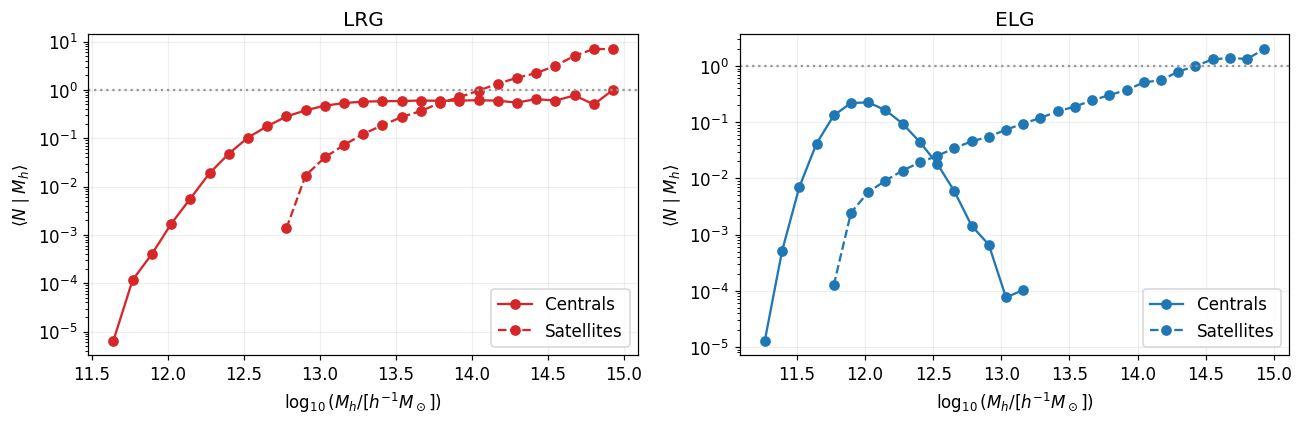

In [8]:
hod_multi = HOD(
    simulation, tracers=["LRG", "ELG"],
    LRG=deepcopy(LRG_PARAMETERS), ELG=deepcopy(ELG_PARAMETERS),
    clustering_settings=deepcopy(CLUSTERING_SETTINGS),
    use_particles=USE_PARTICLES, use_assembly_bias=False,
    nthreads=NTHREADS, seed=FIX_SEED,
)
mock_multi = hod_multi.make_mock_cat(fix_seed=FIX_SEED)
mock_lrg = mock_multi[mock_multi["TRACER"] == "LRG"]
mock_elg = mock_multi[mock_multi["TRACER"] == "ELG"]
describe_mock(mock_multi)
plot_occupations(mock_multi, ["LRG", "ELG"])

### Auto- and cross-clustering

The measurements include `LRG_LRG`, `LRG_ELG`, and `ELG_ELG`.
The cross-correlation probes the relationship between the two populations
within this jointly populated simulation.

Measured pairs: ['LRG_LRG', 'LRG_ELG', 'ELG_ELG']


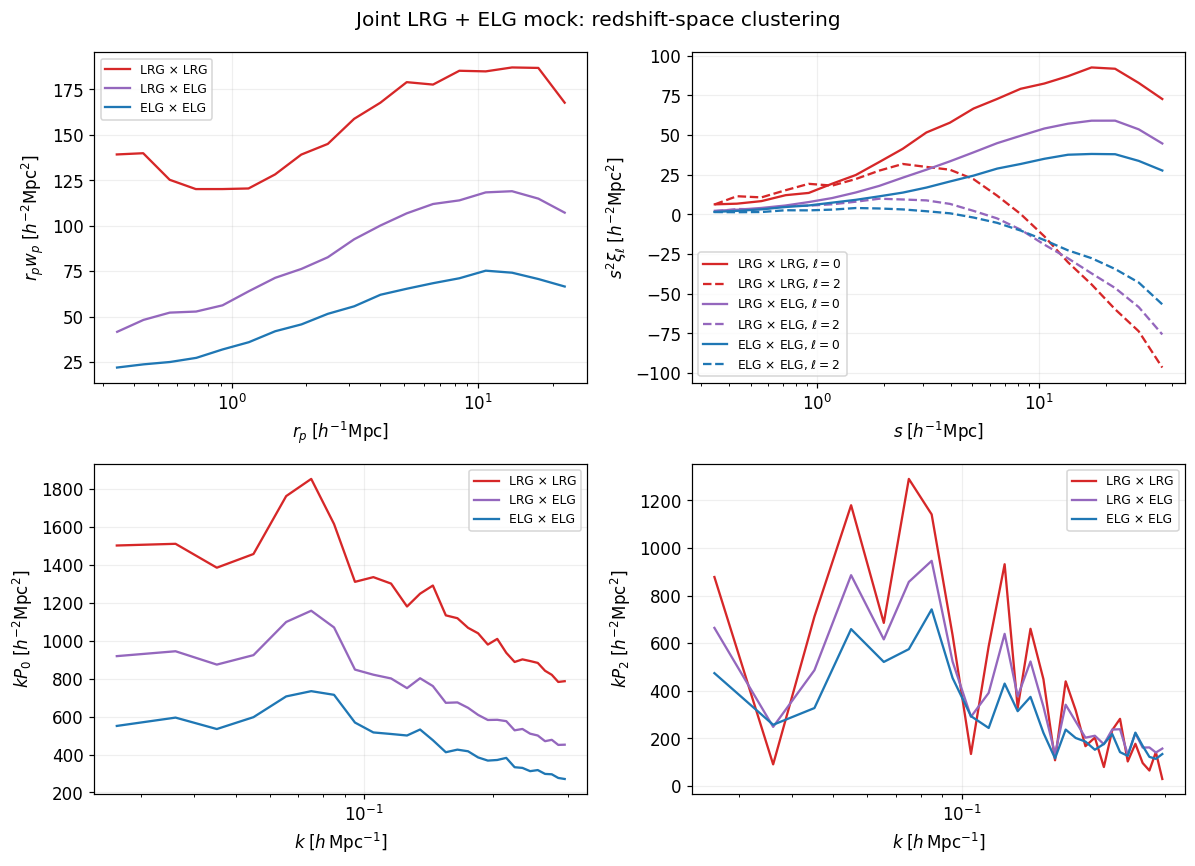

In [9]:
stats_multi = measure_clustering(hod_multi, mock_multi, ["LRG", "ELG"])
print("Measured pairs:", list(stats_multi["wp"]))
plot_clustering(stats_multi, "Joint LRG + ELG mock: redshift-space clustering")

## 6. Estimate the galaxy bias

On large scales in **real space**, approximate the galaxy auto-spectrum as
$P_{gg}(k)\simeq b_g^2 P_{mm}^{\rm lin}(k,z)$.
Remeasure each existing mock with RSD disabled and compare its
Poisson-shot-noise-subtracted monopole with the linear **total matter** spectrum
from the simulation's Abacus cosmology at the same redshift.

Over $0.03\leq k\leq0.10\,h\,\mathrm{Mpc}^{-1}$, fit the amplitude
$A=b_g^2$ by unweighted least squares:
$$A=\frac{\sum_k P_{mm}^{\rm lin}(k)P_{gg}(k)}
{\sum_k[P_{mm}^{\rm lin}(k)]^2},\qquad b_g=\sqrt{A}.$$
This is an illustrative bias estimate: the small-box volume, nonlinear effects,
and departures from Poisson shot noise limit its precision. The shaded region
below shows the fitting interval; no statistical uncertainty is estimated.

LRG (single)    b_g = 1.827
LRG (joint)     b_g = 1.827
ELG (joint)     b_g = 1.060


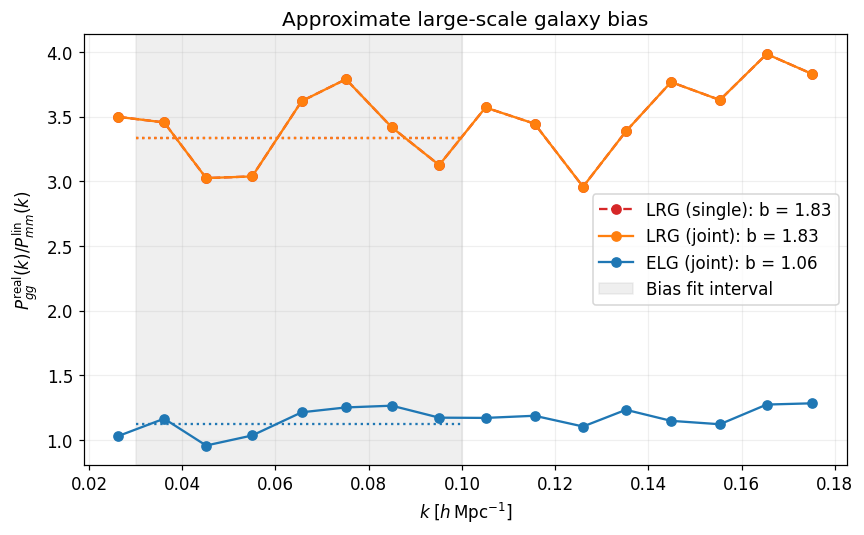

In [10]:
def estimate_bias(hod, mock, tracer, kmin=0.03, kmax=0.10):
    previous_rsd = hod.args["clustering_settings"]["rsd"]
    try:
        hod.args["clustering_settings"]["rsd"] = False
        k, poles = hod.get_PS(mock, tracers=tracer, ells=[0], verbose=False)
    finally:
        hod.args["clustering_settings"]["rsd"] = previous_rsd

    pgal = np.asarray(poles)[0]  # Auto shot noise is already subtracted.
    plin = hod.cosmo.get_fourier().pk_interpolator(of="delta_m")(k, z=hod.z_simu)
    finite = np.isfinite(pgal) & np.isfinite(plin) & (plin > 0)
    fit = finite & (k >= kmin) & (k <= kmax)
    if np.count_nonzero(fit) < 3:
        raise ValueError("Too few finite k bins in the bias fitting interval.")
    amplitude = np.sum(plin[fit] * pgal[fit]) / np.sum(plin[fit] ** 2)
    if amplitude <= 0:
        raise ValueError("The fitted bias-squared amplitude is not positive.")
    return k[finite], pgal[finite] / plin[finite], np.sqrt(amplitude)

bias_results = {}
fig, ax = plt.subplots(figsize=(8, 5))
cases = [
    ("LRG (single)", hod_single, mock_single, "LRG", "tab:red", "--"),
    ("LRG (joint)", hod_multi, mock_multi, "LRG", "tab:orange", "-"),
    ("ELG (joint)", hod_multi, mock_multi, "ELG", "tab:blue", "-"),
]
for label, hod, mock, tracer, color, style in cases:
    k, ratio, bias = estimate_bias(hod, mock, tracer)
    bias_results[label] = bias
    visible = k <= 0.18
    ax.plot(k[visible], ratio[visible], style, marker="o", color=color,
            label=f"{label}: b = {bias:.2f}")
    ax.hlines(bias**2, 0.03, 0.10, color=color, ls=":")
    print(f"{label:<15} b_g = {bias:.3f}")
ax.axvspan(0.03, 0.10, color="0.7", alpha=0.2, label="Bias fit interval")
ax.set_xlabel(r"$k\;[h\,\mathrm{Mpc}^{-1}]$")
ax.set_ylabel(r"$P_{gg}^{\rm real}(k)/P_{mm}^{\rm lin}(k)$")
ax.set_title("Approximate large-scale galaxy bias")
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
plt.show()

## 7. Optional: save the mock catalogues

The catalogues remain available as `mock_single` and `mock_multi`, with the
joint tracer subsets in `mock_lrg` and `mock_elg`. Set the flag below to save
compressed NumPy files beside the notebook. The simulation files are only read.

In [11]:
SAVE_CATALOGUES = False
if SAVE_CATALOGUES:
    output_dir = (repo_root / "Notebooks" if repo_root is not None else Path.cwd()) / "outputs"
    output_dir.mkdir(parents=True, exist_ok=True)
    columns = ["x", "y", "z", "vx", "vy", "vz", "halo_id", "log10_Mh", "TRACER", "Central"]
    for name, mock in [("lrg_single", mock_single), ("lrg_elg_joint", mock_multi)]:
        filename = output_dir / f"abacus_small_{name}.npz"
        np.savez_compressed(filename, **{column: mock[column] for column in columns})
        print("Saved", filename)